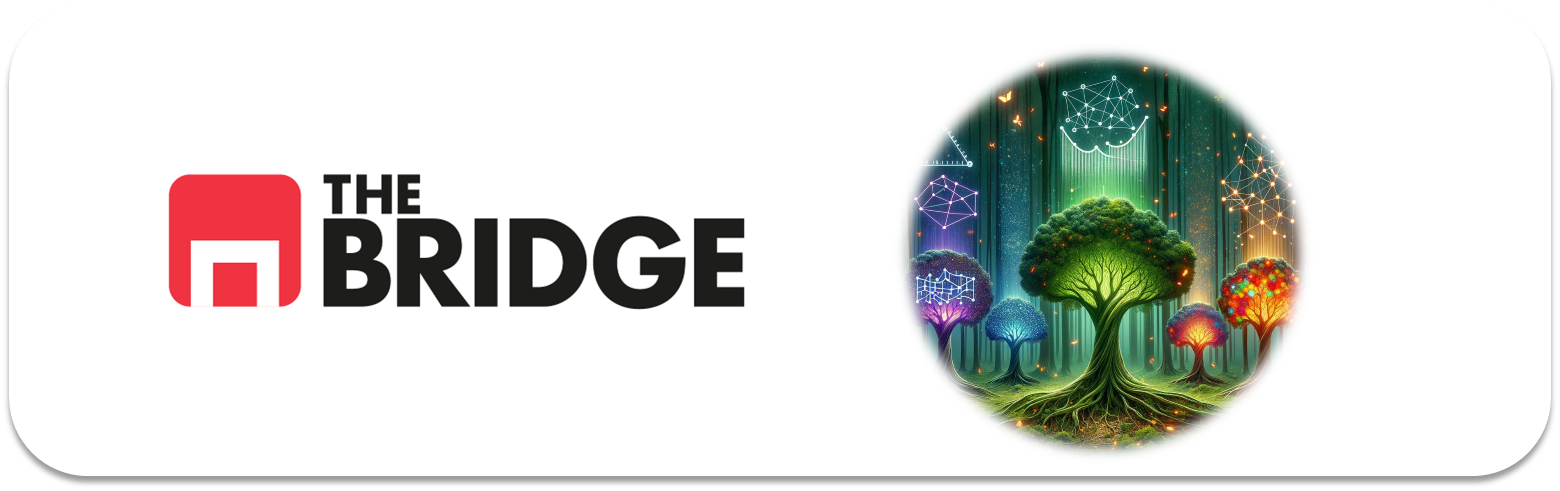

## PRACTICA OBLIGATORIA: **Arboles de Decisión y Ajuste de Hiperparámetros**

* La práctica obligatoria de esta unidad consiste en encontrar el mejor modelo para resolver un problema de predicción de si los destinatarios de una campaña de marketing adquirirán un producto concreto. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import cross_val_score, GridSearchCV, RandomizedSearchCV, train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, DecisionTreeRegressor
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
import matplotlib.pyplot as plt

### Descripción

En el directorio data encontrarás un dataset que contiene datos relacionados con campañas de marketing directo de una institución bancaria portuguesa (es el dataset "Bank Marketing" de la UCI Machine Learning Repository). Los datos se recopilaron de campañas de marketing telefónico, donde el objetivo principal era predecir si el cliente se suscribiría a un depósito a plazo.

La práctica consiste en completar el proceso de creación de un modelo basado en árboles de decisión que permita predecir si un cliente (dadas unas características similares a las del dataset) "comprará" el depósito a plazo. Sigue los pasos necesarios de un proceso de ML para crear el modelo, optimizar sus hiperparámetros, comparar los resultados de esa optimización con una regresión logística (sin optimizar, con sus hiperparámetros por defecto) y finalmente evaluarlo contra test y hacer una pequeña valoración del resultado obtenido.

Tendrás que hacer la limpieza, split, minieda, selección, tratamiento, primeros entrenamientos, optimización, comparación y evaluación según tu mejor criterio. Eso sí, es obligatorio:
- Identificar el target y analizar su distribución
- Realizar una optimización de hiperparámetros, escogiendo un grid medianemante razonado
- Comparar con el modelo baseline
- Evaluar contra test

AYUDA: La dirección del banco nos proporciona estas notas (en inglés):

 
   **bank client data:**  
   1 - age (numeric)  
   2 - job : type of job (categorical: "admin.","unknown","unemployed","management","housemaid","entrepreneur","student",
                                       "blue-collar","self-employed","retired","technician","services")   
   3 - marital : marital status (categorical: "married","divorced","single"; note: "divorced" means divorced or widowed)  
   4 - education (categorical: "unknown","secondary","primary","tertiary")  
   5 - default: has credit in default? (binary: "yes","no")  
   6 - balance: average yearly balance, in euros (numeric)   
   7 - housing: has housing loan? (binary: "yes","no")  
   8 - loan: has personal loan? (binary: "yes","no")   

   **related with the last contact of the current campaign:**  
   9 - contact: contact communication type (categorical: "unknown","telephone","cellular")   
  10 - day: last contact day of the month (numeric)  
  11 - month: last contact month of year (categorical: "jan", "feb", "mar", ..., "nov", "dec")  
  12 - duration: last contact duration, in seconds (numeric)    

   **other attributes:**  
  13 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)  
  14 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric, -1 means client was not previously contacted)  
  15 - previous: number of contacts performed before this campaign and for this client (numeric)  
  16 - poutcome: outcome of the previous marketing campaign (categorical: "unknown","other","failure","success")

  

## 1. Importación y limpieza

In [2]:
bank_data = pd.read_csv(".\\data\\bank-full.csv", sep=";")

In [3]:
bank_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [4]:
bank_data.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [5]:
any(bank_data.duplicated())

False

## 2. Variable target

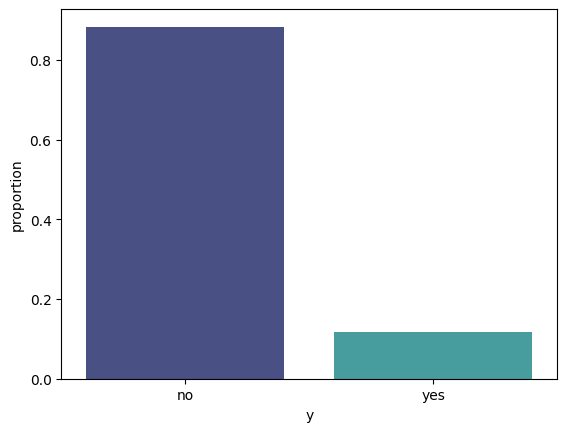

In [6]:
sns.countplot(bank_data, x="y", hue="y", palette="mako", stat="proportion");

Tenemos una proporción de "faltas de puntualidad" del pago frente a puntualidad de pago que claramente va a condicionar la habilidad de predicción del modelo, dado que queremos predecir el "yes", que tiene muchos menos registros.

## 3. Split Train-Test

In [7]:
train_set, test_set = train_test_split(bank_data, test_size = 0.20, random_state=51)

## 4. Mini-EDA

In [8]:
from funciones import diagramas_barras, boxplot_histograma, histograma_por_categorias, comparar_cualitativas

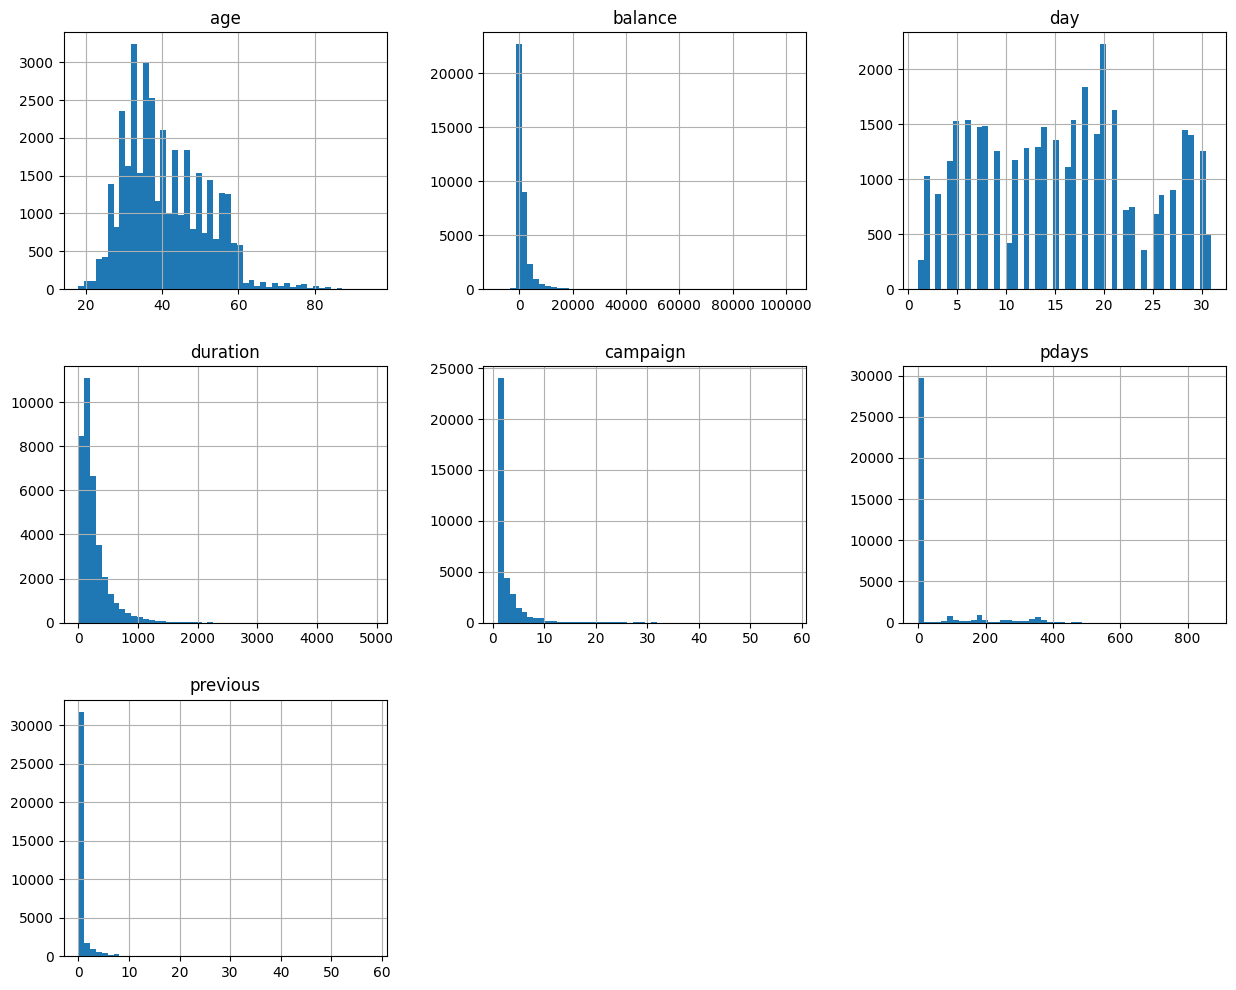

In [9]:
train_set.hist(bins=50, figsize=(15, 12))
plt.show()

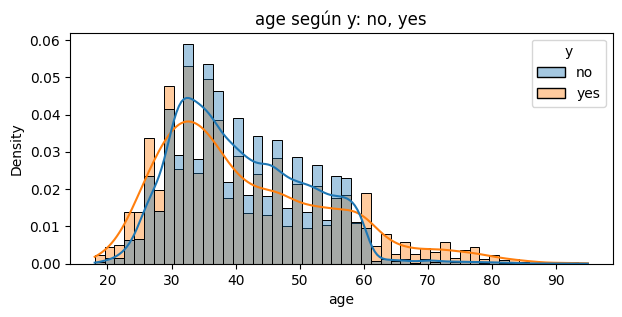

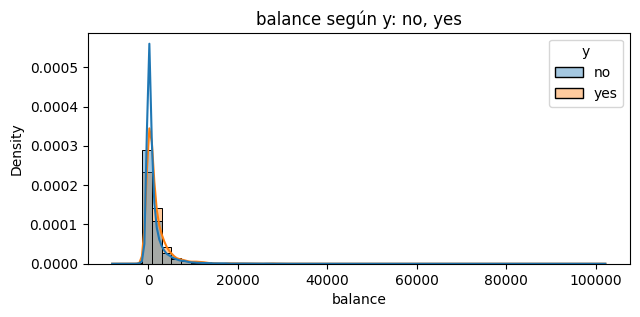

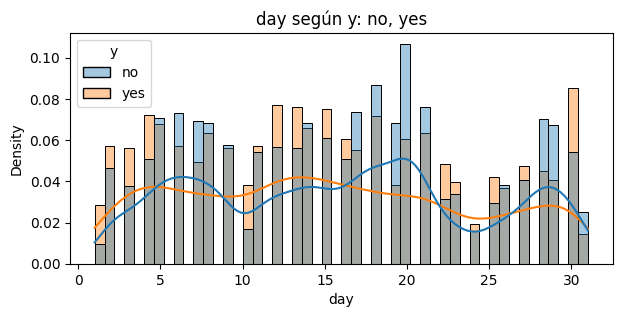

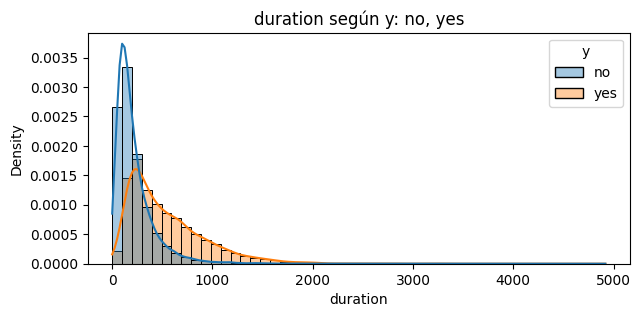

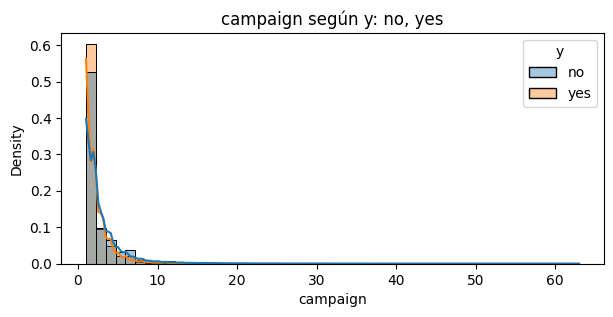

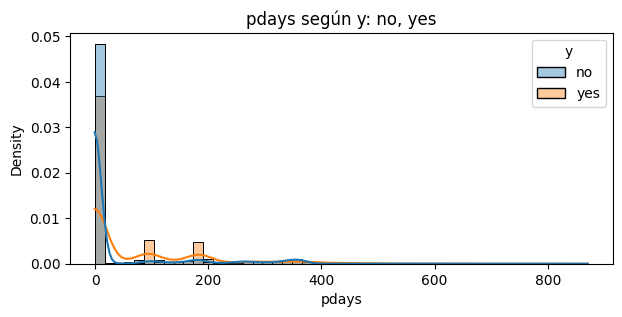

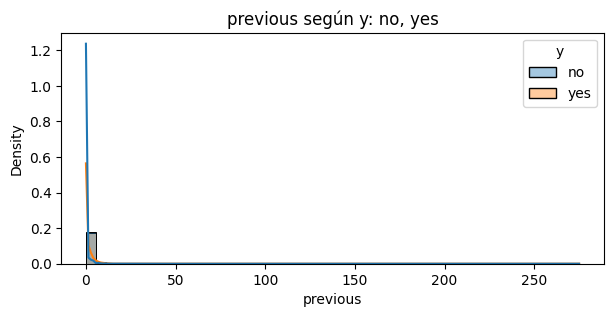

In [10]:
vars_num = ["age", "balance", "day", "duration", "campaign", "pdays", "previous"]
for var in vars_num:
    histograma_por_categorias(bank_data, var, "y", bins=50, estadistico="density", common_norm=False)

In [11]:
from scipy import stats
num_significativas = []
for var in vars_num:
    clases = [clase for clase in train_set.y.unique()]
    grupos = [train_set.loc[train_set.y == clase][var] for clase in clases]
    print(f"ANOVA para las poblaciones de {var} según la compra en plazo:")
    stat, pval = stats.f_oneway(*grupos)
    print(f"F: {stat}, p-valor: {pval}")
    print()
    if pval < 0.05:
        num_significativas.append(var)

ANOVA para las poblaciones de age según la compra en plazo:
F: 17.108164538096442, p-valor: 3.5389877523069627e-05

ANOVA para las poblaciones de balance según la compra en plazo:
F: 75.79795551840724, p-valor: 3.272791526843834e-18

ANOVA para las poblaciones de day según la compra en plazo:
F: 29.085606256862608, p-valor: 6.968313025219106e-08

ANOVA para las poblaciones de duration según la compra en plazo:
F: 6727.37510823892, p-valor: 0.0

ANOVA para las poblaciones de campaign según la compra en plazo:
F: 196.7154635384094, p-valor: 1.4241233830925195e-44

ANOVA para las poblaciones de pdays según la compra en plazo:
F: 370.9683737405042, p-valor: 2.977828548825383e-82

ANOVA para las poblaciones de previous según la compra en plazo:
F: 448.93646374806747, p-valor: 4.924241728290234e-99



In [12]:
num_significativas == vars_num

True

In [13]:
# plt.figure(figsize=(7,7))
# sns.heatmap(train_set[vars_num].corr(), vmin=-1, vmax=1, annot=True, cmap=cmap_corr, fmt=".2f", annot_kws={"size": 7});

In [14]:
vars_cat = list(set(train_set.columns).difference(set(vars_num)))
vars_cat.remove("y")
vars_cat

['contact',
 'housing',
 'default',
 'month',
 'education',
 'marital',
 'loan',
 'poutcome',
 'job']

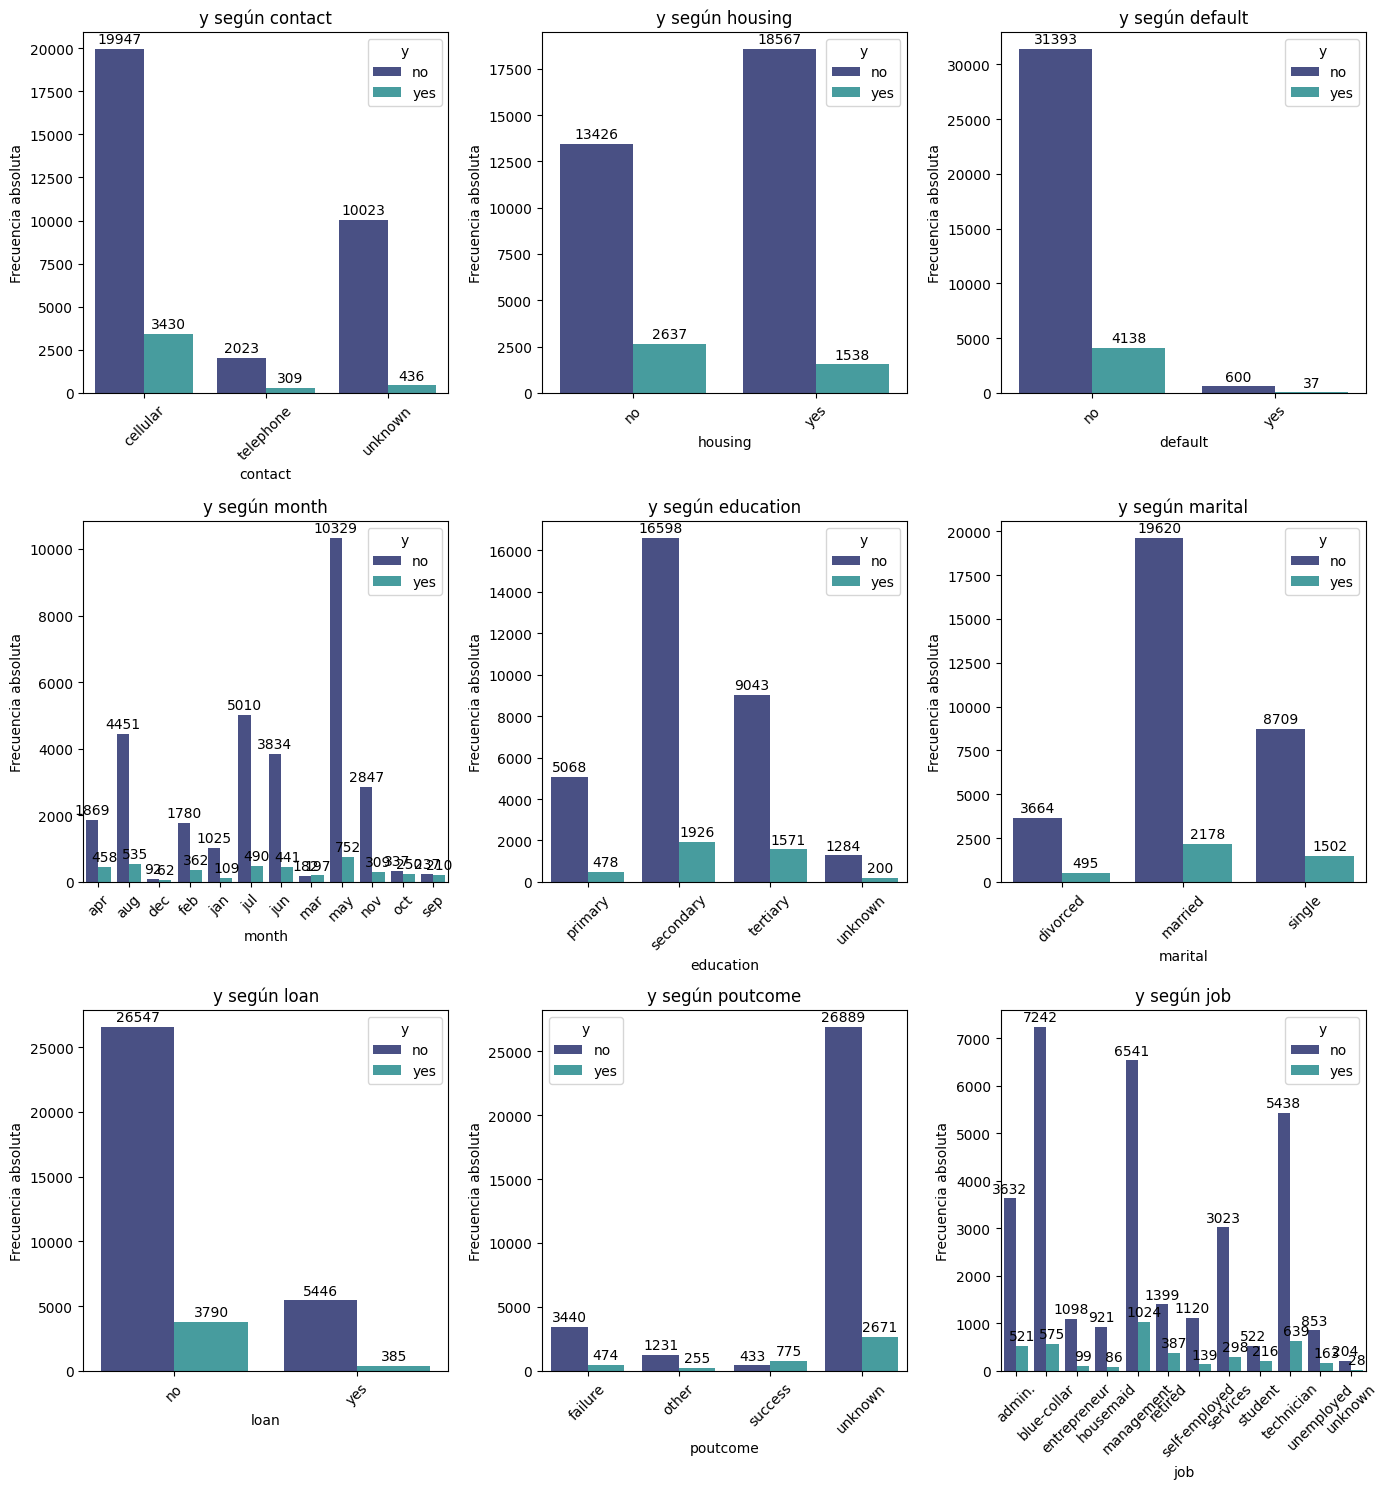

In [15]:
comparar_cualitativas(train_set, "y", *vars_cat, ncols=3)

In [16]:
from scipy.stats import chi2_contingency
cat_significativas = []
for var in vars_cat:
    tabla_contingencia = pd.crosstab(train_set.y, train_set[var])

    chi2, pval, dof, expected = chi2_contingency(tabla_contingencia)
    print(f"TEST CHI CUADRADO: y - {var}")
    print("Valor Chi-Cuadrado:", chi2)
    print("P-Value:", pval)
    print()
    if pval < 0.05:
        cat_significativas.append(var)

TEST CHI CUADRADO: y - contact
Valor Chi-Cuadrado: 787.9093727786196
P-Value: 8.084507740656284e-172

TEST CHI CUADRADO: y - housing
Valor Chi-Cuadrado: 671.2250482781491
P-Value: 5.409960167394075e-148

TEST CHI CUADRADO: y - default
Valor Chi-Cuadrado: 20.31756533806984
P-Value: 6.559561918008398e-06

TEST CHI CUADRADO: y - month
Valor Chi-Cuadrado: 2352.3485270249257
P-Value: 0.0

TEST CHI CUADRADO: y - education
Valor Chi-Cuadrado: 186.0424049197872
P-Value: 4.3698542695591364e-40

TEST CHI CUADRADO: y - marital
Valor Chi-Cuadrado: 152.17272700315044
P-Value: 9.038829267611874e-34

TEST CHI CUADRADO: y - loan
Valor Chi-Cuadrado: 165.61618120419885
P-Value: 6.709776140059819e-38

TEST CHI CUADRADO: y - poutcome
Valor Chi-Cuadrado: 3503.920305945512
P-Value: 0.0

TEST CHI CUADRADO: y - job
Valor Chi-Cuadrado: 643.888458386815
P-Value: 5.670846001566227e-131



In [17]:
cat_significativas == vars_cat

True

## 5. Selección y tratamiento de features
Outcome tiene mucho unknown sesgando los resultados, y en month hay un pico enorme en mayo que no sabemos explicar que está haciendo que sea muy significativo el test.
Todas las variables son significativas, vamos a coger las más significativas:
- housing
- loan
- previous
- pdays
- duration

No se considera job porque su tratamiento requiere necesariamente la creación de variables únicas por cada categoría, lo que aumentaría el número de variables notablemente.

La variable contact tiene muchos unknown que van a condicionar la clasificación sin aportar información, por lo que se ha excluido del modelo.

In [18]:
print(train_set.housing.unique(), train_set.loan.unique())

['no' 'yes'] ['no' 'yes']


In [19]:
train_set["y"]= (train_set["y"] == "yes").astype(int)
test_set["y"]= (test_set["y"] == "yes").astype(int)

train_set["housing"]= (train_set.housing == "yes").astype(int)
test_set["housing"]= (test_set.housing == "yes").astype(int)

train_set["loan"]= (train_set.loan == "yes").astype(int)
test_set["loan"]= (test_set.loan == "yes").astype(int)

In [20]:
features = ["housing", "loan", "previous", "duration"]
target = "y"
X_train = train_set[features]
y_train = train_set[target]
X_test = test_set[features]
y_test = test_set[target]

In [21]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape, sep="\n")

(36168, 4)
(9043, 4)
(36168,)
(9043,)


In [22]:
# Nos aseguramos de que tienen una distribución parecida
print(y_train.value_counts(True), y_test.value_counts(True), sep="\n"*2)

y
0    0.884566
1    0.115434
Name: proportion, dtype: float64

y
0    0.876811
1    0.123189
Name: proportion, dtype: float64


## 6. Regresión
#### Modelo base:

In [23]:
tree_reg4 = DecisionTreeRegressor(max_depth=4, random_state=42)
tree_reg4.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",4
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max

In [24]:
tree_reg5 = DecisionTreeRegressor(max_depth=5, random_state=42)
tree_reg5.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max

In [25]:
# Error de entrenamiento de reg 4
y_pred = tree_reg4.predict(X_train)

print("MAE:", mean_absolute_error(y_train, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_train, y_pred)))

MAE: 0.15418783802254338
RMSE: 0.27765791724939465


In [26]:
level_4 = np.sqrt(-cross_val_score(tree_reg4, X_train, y_train, cv = 5, scoring= "neg_mean_squared_error"))
level_5 = np.sqrt(-cross_val_score(tree_reg5, X_train, y_train, cv = 5, scoring = "neg_mean_squared_error"))

print("Arbol 4 niveles:", level_4.mean())
print("Arbol 5 niveles:", level_5.mean())

Arbol 4 niveles: 0.2793407249152073
Arbol 5 niveles: 0.2778107490241736


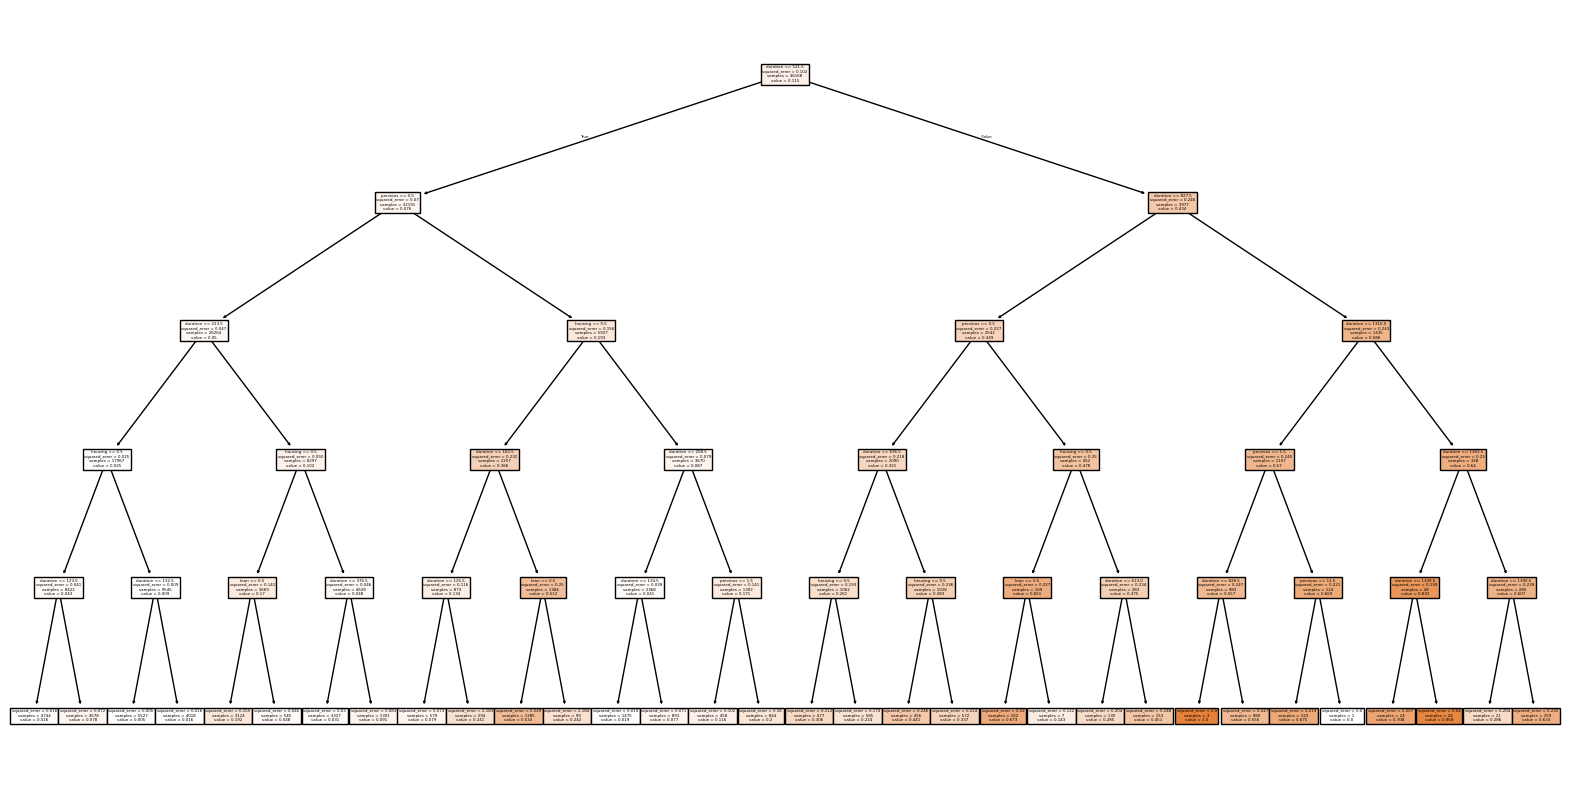

In [27]:
plt.figure(figsize=(20,10))
plot_tree(tree_reg5, feature_names = features, filled=True); 

In [28]:
# Comparemos con el test para la regresión con 5 niveles
y_pred = tree_reg5.predict(X_train)

print("MAE train:", mean_absolute_error(y_train, y_pred))
print("RMSE train:", np.sqrt(mean_squared_error(y_train, y_pred)))
print()

y_tst_pred = tree_reg5.predict(X_test)

print("MAE test:", mean_absolute_error(y_test, y_tst_pred))
print("RMSE test:", np.sqrt(mean_squared_error(y_test, y_tst_pred)))

MAE train: 0.15139016486776352
RMSE train: 0.2751273930997816

MAE test: 0.15709128911466524
RMSE test: 0.2855135062539646


No hay mucha diferencia entre train y test, aunque es un error bastante alto. Veamos cómo sale con una optimización bayesiana:

In [29]:
def hyperopt_train_test(params, scoring = "r2"):
    model = ElasticNet(**params)
    return cross_val_score(model, X_train, y_train, cv=5, scoring= scoring).mean()

space = {'alpha': hp.uniform('alpha', 0.0001, 1.0),
    'l1_ratio': hp.uniform('l1_ratio', 0.0001, 1.0)
}

def f(params):
    r2 = hyperopt_train_test(params)
    return {'loss':-r2, 'status': STATUS_OK}

trials = Trials()
best = fmin(f, space, algo=tpe.suggest, max_evals=100, trials=trials)

100%|██████████| 100/100 [00:07<00:00, 12.55trial/s, best loss: -0.19251341052102067]


In [30]:
best

{'alpha': np.float64(0.000381515701130971),
 'l1_ratio': np.float64(0.6341335432705959)}

In [31]:
model_bayes = ElasticNet(alpha=best['alpha'], l1_ratio=best['l1_ratio'])
model_bayes.fit(X_train, y_train)
model_bayes.score(X_test, y_test)

0.16214384068090637

El modelo lineal tiene un error mucho menor comparado con los árboles con los parámetros dados. Habiendo tantos factores que puedan afectar al resultado de comprar el depósito a plazo, es de esperar que un árbol de decisión con 4 variables independientes no acierte tanto.